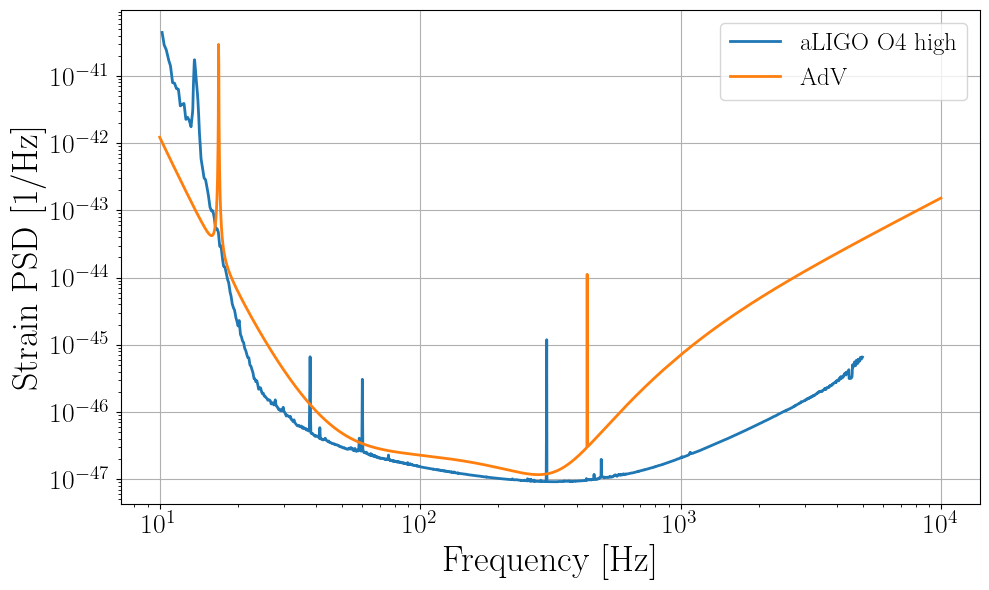

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import bilby

psd_ligo = '../asd_files/aLIGO_O4_high_psd.txt'
psd_virgo = '../asd_files/AdV_psd.txt'

psd_H1 = np.loadtxt(psd_ligo)
# psd_L1 = np.loadtxt(psd_ligo)
psd_V1 = np.loadtxt(psd_virgo)

plt.style.use('~/research/my_plot_style.style')
plt.figure()
plt.loglog(psd_H1[:,0], psd_H1[:,1], label='aLIGO O4 high')
# plt.loglog(psd_L1[:,0], psd_L1[:,1], label='LIGO L1')
plt.loglog(psd_V1[:,0], psd_V1[:,1], label='AdV')
# plt.xlim(10, 2000)
# plt.ylim(1e-48, 1e-39)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Strain PSD [1/Hz]')
plt.legend()
plt.show()

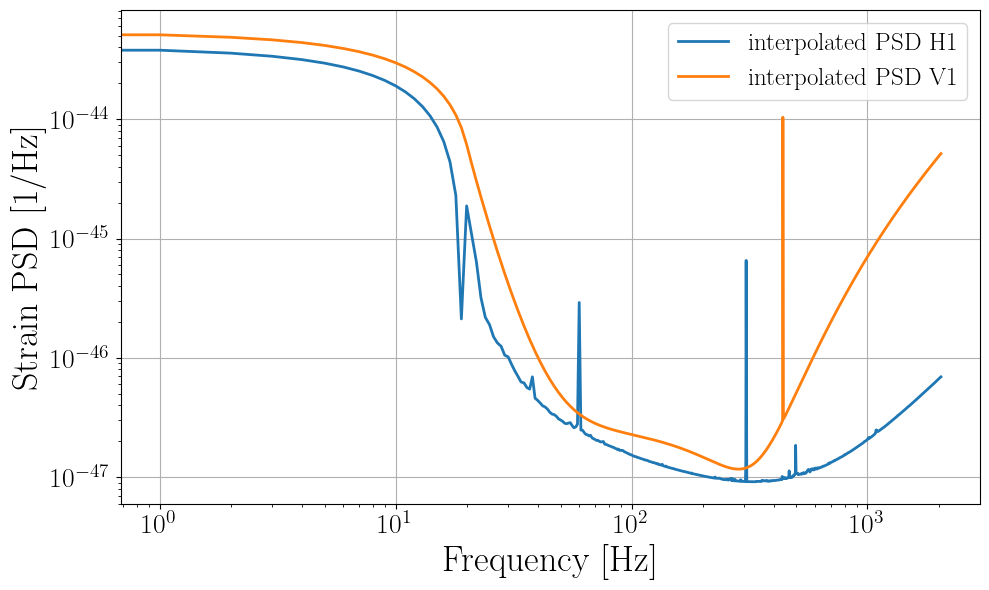

H1 0Hz value: 3.986625182659303e-44
V1 0Hz value: 5.317996315983187e-44


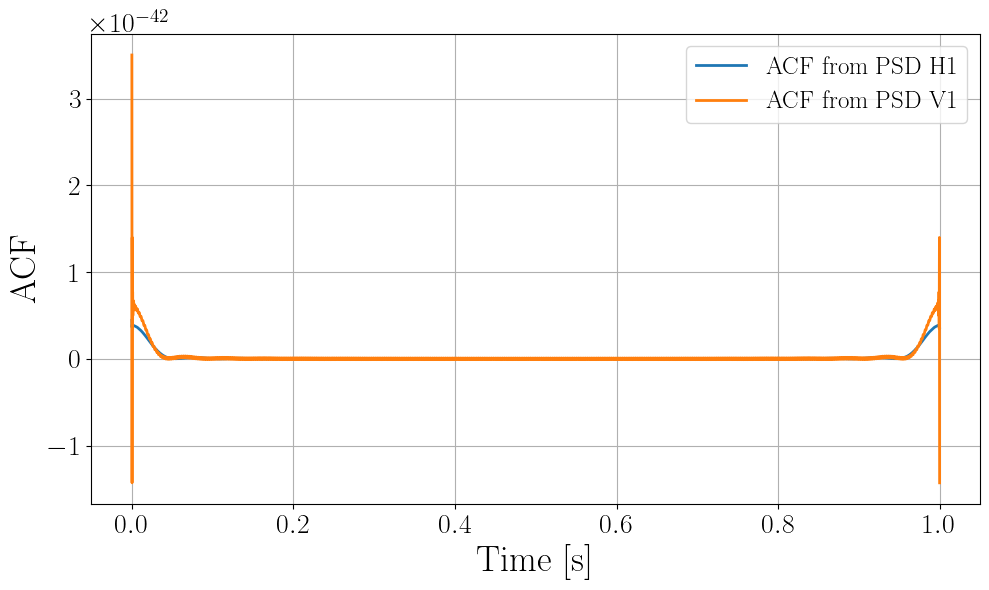

H1 covariance matrix shape: (4096, 4096)
H1 ACF first 10 values: [4.44376422e-43 3.62958097e-43 3.95277744e-43 3.84663695e-43
 3.88486322e-43 3.84894051e-43 3.86052147e-43 3.84202762e-43
 3.84710816e-43 3.83471063e-43]
V1 covariance matrix shape: (4096, 4096)
V1 ACF first 10 values: [ 3.50189850e-42 -1.42835073e-42  1.39896241e-42  3.51464292e-43
  7.71959116e-43  4.99257111e-43  6.76484954e-43  5.57425967e-43
  6.56487220e-43  5.86848428e-43]


In [33]:
import errno
from scipy.interpolate import interp1d
from scipy.linalg import toeplitz

dt = 1.0/4096.0
noise_seglen = 1 * 4096
signal_seglen = 1 * 4096
freqs_from_file_H1, psd_from_file_H1 = psd_H1[:,0], psd_H1[:,1]
freqs_from_file_V1, psd_from_file_V1 = psd_V1[:,0], psd_V1[:,1]

f_min_psd = 20.0
f_max_psd = 2038.0

psd_from_file_H1   = psd_from_file_H1[  freqs_from_file_H1 > f_min_psd]
freqs_from_file_H1 = freqs_from_file_H1[freqs_from_file_H1 > f_min_psd]
psd_from_file_H1   = psd_from_file_H1[  freqs_from_file_H1 < f_max_psd]
freqs_from_file_H1 = freqs_from_file_H1[freqs_from_file_H1 < f_max_psd]

psd_from_file_V1   = psd_from_file_V1[  freqs_from_file_V1 > f_min_psd]
freqs_from_file_V1 = freqs_from_file_V1[freqs_from_file_V1 > f_min_psd]
psd_from_file_V1   = psd_from_file_V1[  freqs_from_file_V1 < f_max_psd]
freqs_from_file_V1 = freqs_from_file_V1[freqs_from_file_V1 < f_max_psd]

psd_from_file_interp_H1           = interp1d(freqs_from_file_H1, psd_from_file_H1, fill_value='extrapolate', bounds_error=False)
psd_from_file_interp_V1           = interp1d(freqs_from_file_V1, psd_from_file_V1, fill_value='extrapolate', bounds_error=False)
freqs_default                  = np.fft.rfftfreq(noise_seglen, d = dt)
df_default                     = np.diff(freqs_default)[0]
psd_interp_H1                     = psd_from_file_interp_H1(freqs_default)
psd_interp_V1                     = psd_from_file_interp_V1(freqs_default)

psd_interp_H1                     = np.abs(psd_interp_H1)
psd_interp_V1                     = np.abs(psd_interp_V1)

plt.figure()
plt.plot(freqs_default, psd_interp_H1, label='interpolated PSD H1')
plt.plot(freqs_default, psd_interp_V1, label='interpolated PSD V1')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Strain PSD [1/Hz]')
plt.legend()
plt.show()

print("H1 0Hz value:", psd_interp_H1[0])
print("V1 0Hz value:", psd_interp_V1[0])

ACF_psd_H1 = 0.5*np.real(np.fft.irfft(psd_interp_H1*df_default))*noise_seglen
ACF_psd_V1 = 0.5*np.real(np.fft.irfft(psd_interp_V1*df_default))*noise_seglen

plt.figure()
plt.plot(np.arange(0, noise_seglen)*dt, ACF_psd_H1, label='ACF from PSD H1')
plt.plot(np.arange(0, noise_seglen)*dt, ACF_psd_V1, label='ACF from PSD V1')
# plt.yscale('log')
plt.xlabel('Time [s]')
plt.ylabel('ACF')
plt.legend()
plt.show()

ACF_signal_H1 = ACF_psd_H1[:signal_seglen]
Covariance_matrix_signal_H1 = toeplitz(ACF_signal_H1)
ACF_signal_V1 = ACF_psd_V1[:signal_seglen]
Covariance_matrix_signal_V1 = toeplitz(ACF_signal_V1)

print("H1 covariance matrix shape:", Covariance_matrix_signal_H1.shape)
print("H1 ACF first 10 values:", ACF_signal_H1[:10])
print("V1 covariance matrix shape:", Covariance_matrix_signal_V1.shape)
print("V1 ACF first 10 values:", ACF_signal_V1[:10])

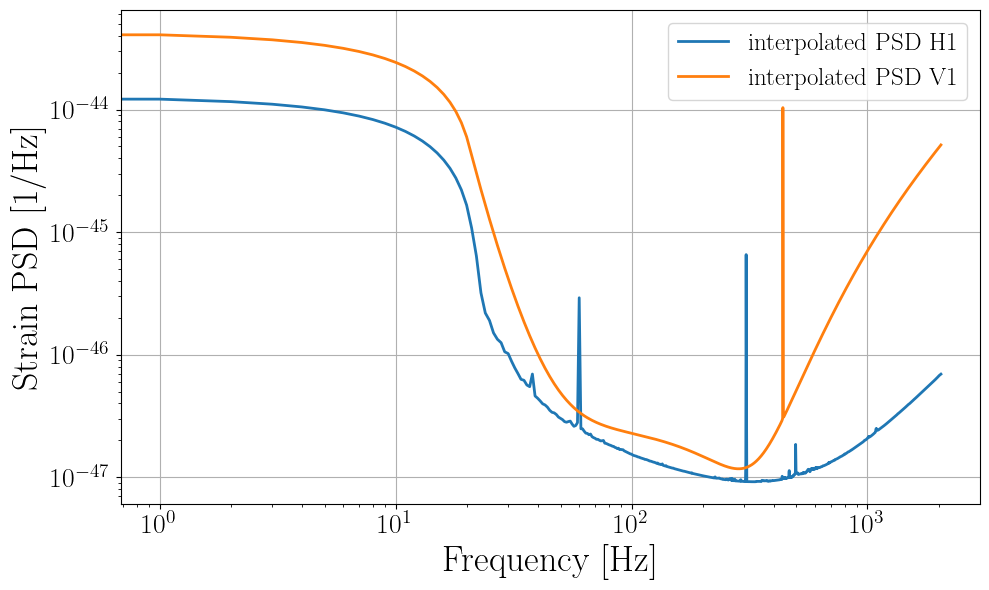

H1 0Hz value: 1.2717898215829546e-44
V1 0Hz value: 4.257824646004027e-44


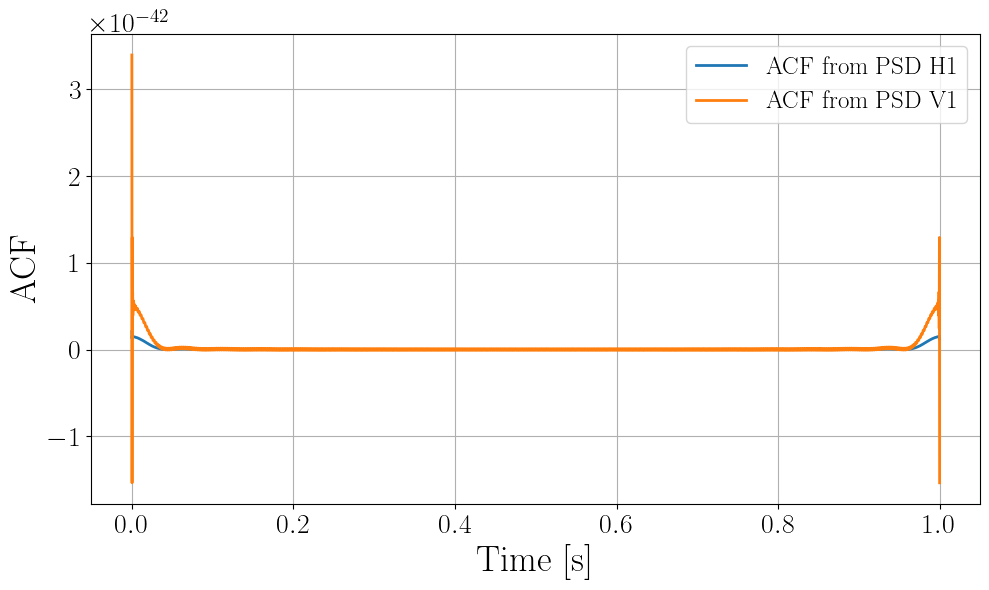

H1 covariance matrix shape: (4096, 4096)
H1 ACF first 10 values: [2.06242025e-43 1.24837540e-43 1.57198701e-43 1.46653830e-43
 1.50573281e-43 1.47105455e-43 1.48415586e-43 1.46745784e-43
 1.47460923e-43 1.46455705e-43]
V1 covariance matrix shape: (4096, 4096)
V1 ACF first 10 values: [ 3.39440590e-42 -1.53583466e-42  1.29150446e-42  2.44049612e-43
  6.64605003e-43  3.91980829e-43  5.69303738e-43  4.50357014e-43
  5.49547686e-43  4.80055416e-43]


In [41]:
import errno
from scipy.interpolate import interp1d
from scipy.linalg import toeplitz

dt = 1.0/4096.0
noise_seglen = 1 * 4096
signal_seglen = 1 * 4096
freqs_from_file_H1, psd_from_file_H1 = psd_H1[:,0], psd_H1[:,1]
freqs_from_file_V1, psd_from_file_V1 = psd_V1[:,0], psd_V1[:,1]

f_min_psd = 20.5
f_max_psd = 2038.0

psd_from_file_H1   = psd_from_file_H1[  freqs_from_file_H1 > f_min_psd]
freqs_from_file_H1 = freqs_from_file_H1[freqs_from_file_H1 > f_min_psd]
psd_from_file_H1   = psd_from_file_H1[  freqs_from_file_H1 < f_max_psd]
freqs_from_file_H1 = freqs_from_file_H1[freqs_from_file_H1 < f_max_psd]

psd_from_file_V1   = psd_from_file_V1[  freqs_from_file_V1 > f_min_psd]
freqs_from_file_V1 = freqs_from_file_V1[freqs_from_file_V1 > f_min_psd]
psd_from_file_V1   = psd_from_file_V1[  freqs_from_file_V1 < f_max_psd]
freqs_from_file_V1 = freqs_from_file_V1[freqs_from_file_V1 < f_max_psd]

psd_from_file_interp_H1           = interp1d(freqs_from_file_H1, psd_from_file_H1, fill_value='extrapolate', bounds_error=False)
psd_from_file_interp_V1           = interp1d(freqs_from_file_V1, psd_from_file_V1, fill_value='extrapolate', bounds_error=False)
freqs_default                  = np.fft.rfftfreq(noise_seglen, d = dt)
df_default                     = np.diff(freqs_default)[0]
psd_interp_H1                     = psd_from_file_interp_H1(freqs_default)
psd_interp_V1                     = psd_from_file_interp_V1(freqs_default)

psd_interp_H1                     = np.abs(psd_interp_H1)
psd_interp_V1                     = np.abs(psd_interp_V1)

plt.figure()
plt.plot(freqs_default, psd_interp_H1, label='interpolated PSD H1')
plt.plot(freqs_default, psd_interp_V1, label='interpolated PSD V1')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Strain PSD [1/Hz]')
plt.legend()
plt.show()

print("H1 0Hz value:", psd_interp_H1[0])
print("V1 0Hz value:", psd_interp_V1[0])

ACF_psd_H1 = 0.5*np.real(np.fft.irfft(psd_interp_H1*df_default))*noise_seglen
ACF_psd_V1 = 0.5*np.real(np.fft.irfft(psd_interp_V1*df_default))*noise_seglen

plt.figure()
plt.plot(np.arange(len(ACF_psd_H1))*dt, ACF_psd_H1, label='ACF from PSD H1')
plt.plot(np.arange(len(ACF_psd_V1))*dt, ACF_psd_V1, label='ACF from PSD V1')
# plt.yscale('log')
plt.xlabel('Time [s]')
plt.ylabel('ACF')
plt.legend()
plt.show()

ACF_signal_H1 = ACF_psd_H1[:signal_seglen]
Covariance_matrix_signal_H1 = toeplitz(ACF_signal_H1)
epsilon = 1e-9 * np.abs(Covariance_matrix_signal_H1[0, 0])
Covariance_matrix_signal_H1 += epsilon * np.eye(Covariance_matrix_signal_H1.shape[0])

ACF_signal_V1 = ACF_psd_V1[:signal_seglen]
Covariance_matrix_signal_V1 = toeplitz(ACF_signal_V1)
epsilon = 1e-9 * np.abs(Covariance_matrix_signal_V1[0, 0])
Covariance_matrix_signal_V1 += epsilon * np.eye(Covariance_matrix_signal_V1.shape[0])

print("H1 covariance matrix shape:", Covariance_matrix_signal_H1.shape)
print("H1 ACF first 10 values:", ACF_signal_H1[:10])
print("V1 covariance matrix shape:", Covariance_matrix_signal_V1.shape)
print("V1 ACF first 10 values:", ACF_signal_V1[:10])